# Reinforcement learning — Q-learning on a grid (planner that learns the map)

Notebook accompanying the subsection **Reinforcement learning as an adaptive planner** from the chapter *LLMs as planners: Reasoning instead of programming*.

## The same task as with Dijkstra, but the agent DOES NOT know the map

The scene is identical to the Dijkstra/A\* notebook: a 25×25 grid with a **river** (column 12) and a single **bridge** (rows 10–14), starting at **home (3, 3)**, goal at **school (21, 21)**.

The difference is fundamental:
- **Dijkstra/A\*** get the map and the cost function **upfront** and *compute* the route.
- **RL Agent** knows neither the obstacle map nor the costs. It **learns** them by trial and error: after each step it gets a reward ($-1$ for a step, $+50$ for reaching the school) and gradually discovers which way to go.

## Intuition: treading a path with reward

Imagine someone walking from home to school every day in a dense fog — **they don't see the map**. They pay for every step with effort ($-1$ penalty), and reaching the goal rewards them ($+50$ bonus). The first journeys are chaotic and long. But over time, remembering which moves in which places *paid off*, they tread an increasingly shorter path.

This is the equivalent of the "tilted table" from A\*, but **the tilt is not given — it is learned**. The value function $V(s)$ that the agent builds is its own map, discovered from experience, of "how close to the goal I am" — an analogy to the cost-to-come $g$ from Dijkstra, except nobody gave it to the agent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

GRID = 25
START = (3, 3)
GOAL = (21, 21)

# Same scene as in Dijkstra notebook: river (column 12) + bridge (rows 10-14)
obstacles = np.zeros((GRID, GRID), dtype=int)
for r in range(GRID):
    if not (10 <= r <= 14):
        obstacles[r, 12] = 1
for c in range(4, 9):
    obstacles[7, c] = 1
for c in range(16, 21):
    obstacles[17, c] = 1

ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right


def krok(stan, a):
    """State after action a; moving off the board or into an obstacle = staying in place."""
    r, c = stan
    dr, dc = ACTIONS[a]
    nr, nc = r + dr, c + dc
    if 0 <= nr < GRID and 0 <= nc < GRID and obstacles[nr, nc] == 0:
        return (nr, nc)
    return (r, c)


print('Scene ready:', obstacles.shape, '| obstacles:', int(obstacles.sum()))
print('HOME', START, '-> SCHOOL', GOAL, '| actions count:', len(ACTIONS))

Scene ready: (25, 25) | obstacles: 30
HOME (3, 3) -> SCHOOL (21, 21) | actions count: 4


## 1. Q-learning implementation (tabular)

The agent maintains a table $Q[s, a]$ — the estimated value of taking action $a$ in state $s$. It learns using the update rule:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\big[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\big]$$

It explores with an $\varepsilon$-greedy strategy (with probability $\varepsilon$ a random move, otherwise the best known), and $\varepsilon$ decreases over time — from curiosity to exploitation of knowledge.

In [2]:
def q_learning(epizody=4000, alpha=0.1, gamma=0.95,
               eps0=1.0, eps_min=0.05, decay=0.999,
               max_krokow=400, nagroda_cel=50.0, seed=0):
    """Tabular Q-learning. Returns the Q table and the sum of rewards in each episode."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((GRID, GRID, len(ACTIONS)))
    zwroty = []
    eps = eps0
    for _ in range(epizody):
        s = START
        suma = 0.0
        for _ in range(max_krokow):
            r, c = s
            # eps-greedy policy: with prob. eps random move (exploration), otherwise a = argmax_a Q(s,a)
            if rng.random() < eps:
                a = int(rng.integers(len(ACTIONS)))
            else:
                a = int(np.argmax(Q[r, c]))
            s2 = krok(s, a)
            cel = (s2 == GOAL)
            nagroda = nagroda_cel if cel else -1.0
            # max_a' Q(s',a') -- Bellman term (best future value); in terminal state (goal) = 0
            best_next = 0.0 if cel else float(np.max(Q[s2[0], s2[1]]))
            # Q-learning rule (eq:qlearning): Q(s,a) <- Q(s,a) + alpha*[ r + gamma*max_a' Q(s',a') - Q(s,a) ]
            Q[r, c, a] += alpha * (nagroda + gamma * best_next - Q[r, c, a])
            suma += nagroda
            s = s2
            if cel:
                break
        zwroty.append(suma)
        eps = max(eps_min, eps * decay)
    return Q, np.array(zwroty)


## 2. Execution and metrics

In [3]:
Q, zwroty = q_learning()

# Value function and greedy policy
V = Q.max(axis=2)                       # Value function: V(s) = max_a Q(s,a) -- learned equivalent of cost-to-come g
V_masked = np.ma.masked_where(obstacles == 1, V)
polityka = Q.argmax(axis=2)             # Greedy policy: pi(s) = argmax_a Q(s,a)


def trasa_zachlanna(Q, maks=200):
    """Follows the greedy policy from start to goal (with loop protection)."""
    s = START
    sciezka = [s]
    odwiedzone = set()
    for _ in range(maks):
        if s == GOAL or s in odwiedzone:
            break
        odwiedzone.add(s)
        a = int(np.argmax(Q[s[0], s[1]]))
        s = krok(s, a)
        sciezka.append(s)
    return sciezka


sciezka = trasa_zachlanna(Q)
dotarl = sciezka[-1] == GOAL
print(f'Episodes: {len(zwroty)} | average reward from last 100 episodes: {zwroty[-100:].mean():.1f}')
print(f'Length of learned path: {len(sciezka)} steps | reached goal: {dotarl}')
print('Note: the agent DID NOT get the map - it worked out this path by trial and error.')


Episodes: 4000 | average reward from last 100 episodes: 13.1
Length of learned path: 37 steps | reached goal: True
Note: the agent DID NOT get the map - it worked out this path by trial and error.


## 3. Visualization

The figure is saved to `../figures/rl_gridworld.pdf` and inserted into the chapter.
- **(a)** learned value function $V(s)=\max_a Q(s,a)$ — *discovered* map of "how close to the goal";
- **(b)** greedy policy (arrows) and the resulting path;
- **(c)** learning curve — the sum of rewards per episode increases during training.

Saved: chapter_5/figures/rl_gridworld.{pdf,png}


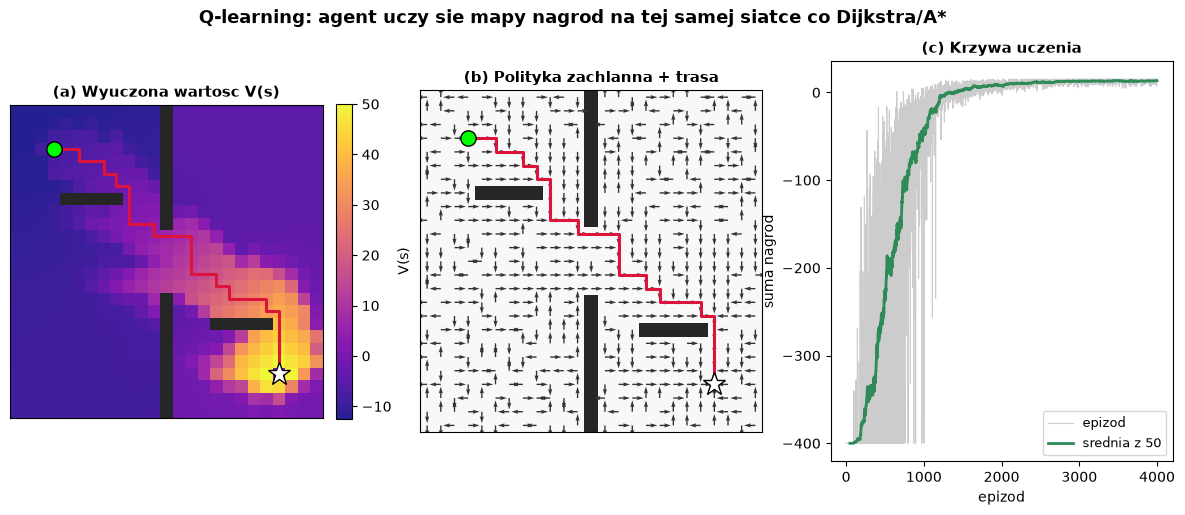

In [4]:
def _tlo(ax):
    ax.imshow(np.where(obstacles == 1, 0.15, 0.97), cmap='gray',
              vmin=0, vmax=1, origin='upper')


def _markery(ax):
    ax.plot(START[1], START[0], 'o', color='lime', markersize=11, markeredgecolor='black')
    ax.plot(GOAL[1], GOAL[0], '*', color='white', markersize=17, markeredgecolor='black')
    ax.set_xticks([])
    ax.set_yticks([])


xs = [p[1] for p in sciezka]
ys = [p[0] for p in sciezka]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))

# (a) funkcja wartosci
ax = axes[0]
_tlo(ax)
im = ax.imshow(V_masked, cmap='plasma', origin='upper', alpha=0.9)
ax.plot(xs, ys, color='crimson', linewidth=2.2)
_markery(ax)
ax.set_title('(a) Learned value V(s)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='V(s)')

# (b) polityka zachlanna
ax = axes[1]
_tlo(ax)
U = np.zeros((GRID, GRID))
Wq = np.zeros((GRID, GRID))
for r in range(GRID):
    for c in range(GRID):
        if obstacles[r, c] == 1:
            continue
        dr, dc = ACTIONS[int(polityka[r, c])]
        U[r, c] = dc
        Wq[r, c] = -dr
RR, CC = np.meshgrid(range(GRID), range(GRID), indexing='ij')
maska = obstacles == 0
ax.quiver(CC[maska], RR[maska], U[maska], Wq[maska], color='0.2', scale=30, width=0.004)
ax.plot(xs, ys, color='crimson', linewidth=2.2)
_markery(ax)
ax.set_title('(b) Greedy policy + path', fontsize=11, fontweight='bold')

# (c) krzywa uczenia
ax = axes[2]
okno = 50
gladka = np.convolve(zwroty, np.ones(okno) / okno, mode='valid')
ax.plot(zwroty, color='0.8', linewidth=0.8, label='episode')
ax.plot(range(okno - 1, len(zwroty)), gladka, color='seagreen', linewidth=2.0, label=f'average of {okno}')
ax.set_xlabel('episode')
ax.set_ylabel('sum of rewards')
ax.set_title('(c) Learning curve', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

fig.suptitle('Q-learning: agent learns the reward map on the same grid as Dijkstra/A*',
             fontsize=13, fontweight='bold')

os.makedirs('../rysunki', exist_ok=True)
fig.savefig('../figures/rl_gridworld.pdf', bbox_inches='tight')
fig.savefig('../figures/rl_gridworld.png', dpi=150, bbox_inches='tight')
print('Saved: chapter_5/figures/rl_gridworld.{pdf,png}')
plt.show()

## 4. Wnioski

- **Same problem, different tool.** Dijkstra/A\* *receive* the map and compute the route; the Q-learning agent **discovers** it through trial and error, building its own value function $V(s)$ (panel a) — the learned equivalent of the cost-to-come $g$.
- **Adaptability comes at a cost.** The learning curve (panel c) shows how many episodes are needed before the policy becomes reasonable — this illustrates the costly training, a weakness of RL compared to classical methods.
- **No hard guarantees.** The route is often good, but there is no optimality guarantee like in A\*; the result depends on rewards, exploration, and the number of episodes.
- This is a tabular, didactic example. In practice, states are often continuous/high-dimensional and the $Q$ table is replaced by a neural network (Deep RL) — which is discussed later in the chapter.